# [1] 로지스틱 회귀

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
!pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import koreanize_matplotlib

In [75]:
# 머신러닝 라이브러리 불러오기

# Step1 : 데이터 준비
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [76]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [77]:
# 간단한 처리 완료
df = df[['survived','pclass','sex','age','fare']].dropna().reset_index(drop=True)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   sex       714 non-null    object 
 3   age       714 non-null    float64
 4   fare      714 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 28.0+ KB


In [79]:
df = pd.get_dummies(df,columns=['sex'],drop_first=True,dtype=int)

In [80]:
df.head()

,survived,pclass,age,fare,sex_male
0,0,3,22.0,7.2500,1
1,1,1,38.0,71.2833,0
2,1,3,26.0,7.9250,0
3,1,1,35.0,53.1000,0
4,0,3,35.0,8.0500,1


In [81]:
X = df.drop('survived',axis=1).copy()
y = df['survived'].copy()

In [82]:
X.shape, y.shape

((714, 4), (714,))

In [83]:
y.value_counts(normalize=True)

survived
0    0.593838
1    0.406162
Name: proportion, dtype: float64

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [85]:
X_train.shape

(571, 4)

In [86]:
X_test.shape

(143, 4)

In [87]:
# step 2 : 모델링 및 평가
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [88]:
model = LogisticRegression(random_state=42)
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [89]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [90]:
model.score(X_test, y_test) # accuracy

0.8041958041958042

In [91]:
y_pred = model.predict(X_test)

In [92]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [93]:
y_pred_proba = model.predict_proba(X_test)

In [94]:
y_pred_proba

array([[0.45756873, 0.54243127],
       [0.77125985, 0.22874015],
       [0.65845676, 0.34154324],
       [0.77433313, 0.22566687],
       [0.93559425, 0.06440575],
       [0.89927589, 0.10072411],
       [0.90900396, 0.09099604],
       [0.93093189, 0.06906811],
       [0.78076329, 0.21923671],
       [0.14011211, 0.85988789],
       [0.41159877, 0.58840123],
       [0.81474995, 0.18525005],
       [0.75410249, 0.24589751],
       [0.71011771, 0.28988229],
       [0.91354646, 0.08645354],
       [0.90587465, 0.09412535],
       [0.78741161, 0.21258839],
       [0.92842935, 0.07157065],
       [0.60657108, 0.39342892],
       [0.95146125, 0.04853875],
       [0.43075862, 0.56924138],
       [0.30430911, 0.69569089],
       [0.34142308, 0.65857692],
       [0.89939884, 0.10060116],
       [0.25197373, 0.74802627],
       [0.10056172, 0.89943828],
       [0.65481551, 0.34518449],
       [0.46696235, 0.53303765],
       [0.35847525, 0.64152475],
       [0.18230109, 0.81769891],
       [0.

In [95]:
# 평가지표 각각 확인하기

# 정밀도
precision = precision_score(y_test, y_pred)
precision

0.7586206896551724

In [96]:
# 재현율
recall = recall_score(y_test, y_pred)
recall

0.7586206896551724

In [97]:
# f1
f1 = f1_score(y_test, y_pred)
f1

0.7586206896551724

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [99]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[71, 14],
       [14, 44]])

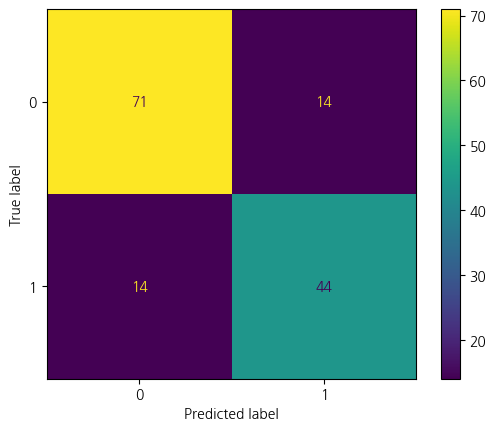

In [100]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [101]:
from sklearn.metrics import roc_curve, roc_auc_score

In [102]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])

In [103]:
auc = roc_auc_score(y_test, y_pred_proba[:,1])

Text(0.5, 1.0, 'ROC 곡선')

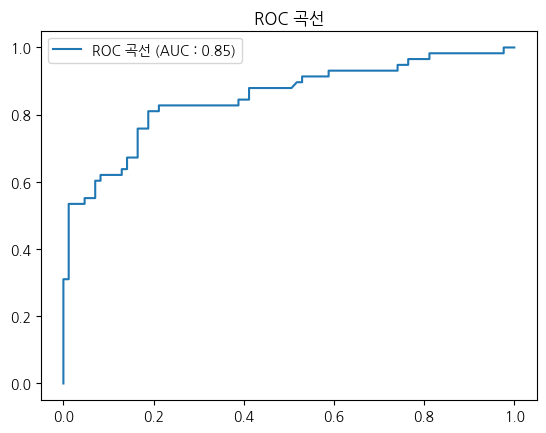

In [104]:
plt.plot(fpr, tpr, label=f'ROC 곡선 (AUC : {auc:.2f})')
plt.legend()
plt.title('ROC 곡선')

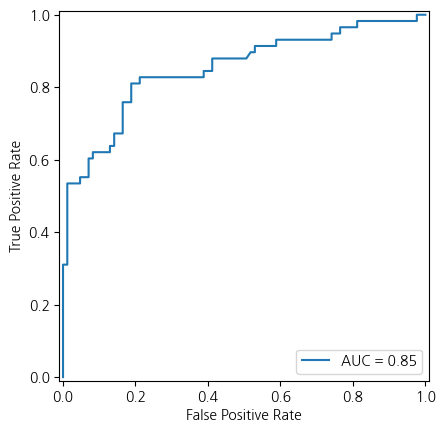

In [105]:
from sklearn.metrics import RocCurveDisplay

disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc)
disp.plot()

# [2] 의사결정나무

In [106]:
X_train.shape, y_train.shape

((571, 4), (571,))

In [107]:
X_test.shape, y_test.shape

((143, 4), (143,))

In [108]:
from sklearn.tree import DecisionTreeClassifier

In [109]:
dt_cls = DecisionTreeClassifier(random_state=42,
                                 max_depth=3)
dt_cls

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [110]:
dt_cls.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [111]:
# 정확도

dt_cls.score(X_test, y_test)

0.8111888111888111

In [112]:
y_pred_dt = dt_cls.predict(X_test)

In [113]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84        85
           1       0.75      0.79      0.77        58

    accuracy                           0.81       143
   macro avg       0.80      0.81      0.81       143
weighted avg       0.81      0.81      0.81       143



In [114]:
f1_score(y_test, y_pred_dt)

0.773109243697479

In [115]:
precision_score(y_test, y_pred_dt)

0.7540983606557377

In [116]:
recall_score(y_test, y_pred_dt)

0.7931034482758621

In [117]:
X.columns.to_list()

['pclass', 'age', 'fare', 'sex_male']

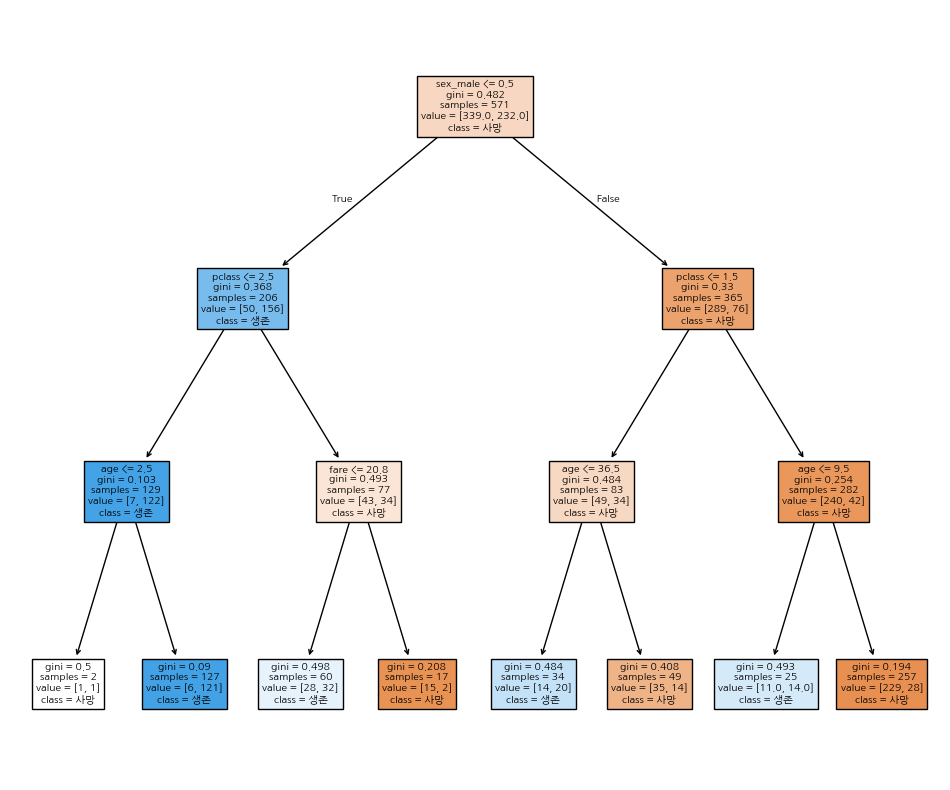

In [118]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,10))
plot_tree(dt_cls,
          feature_names=X.columns.to_list(),
          class_names=['사망','생존'],
          filled=True,
          max_depth=3)

plt.show();

In [119]:
feature_imp = pd.Series(dt_cls.feature_importances_, index=X.columns.to_list())
feature_imp.sort_values(ascending=False)

sex_male    0.606278
pclass      0.253754
age         0.105010
fare        0.034958
dtype: float64

In [120]:
cm = confusion_matrix(y_test, y_pred_dt)
cm

array([[70, 15],
       [12, 46]])

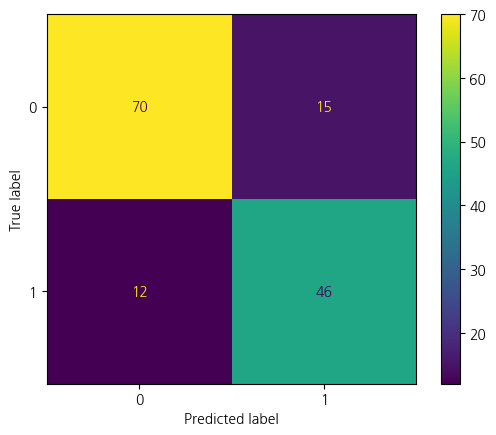

In [121]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [122]:
y_pred_proba_dt = dt_cls.predict_proba(X_test)
y_pred_proba_dt

array([[0.46666667, 0.53333333],
       [0.46666667, 0.53333333],
       [0.88235294, 0.11764706],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.04724409, 0.95275591],
       [0.46666667, 0.53333333],
       [0.44      , 0.56      ],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.89105058, 0.10894942],
       [0.71428571, 0.28571429],
       [0.89105058, 0.10894942],
       [0.41176471, 0.58823529],
       [0.04724409, 0.95275591],
       [0.46666667, 0.53333333],
       [0.89105058, 0.10894942],
       [0.04724409, 0.95275591],
       [0.04724409, 0.95275591],
       [0.89105058, 0.10894942],
       [0.46666667, 0.53333333],
       [0.46666667, 0.53333333],
       [0.04724409, 0.95275591],
       [0.

In [123]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_dt[:,1])

In [124]:
auc = roc_auc_score(y_test, y_pred_proba_dt[:,1])

Text(0.5, 1.0, 'ROC 곡선')

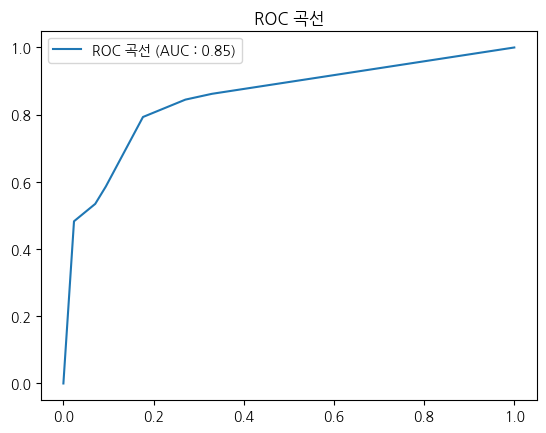

In [125]:
plt.plot(fpr, tpr, label=f'ROC 곡선 (AUC : {auc:.2f})')
plt.legend()
plt.title('ROC 곡선')

# [3] 배깅 : 랜덤 포레스트

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, RocCurveDisplay


In [127]:
from sklearn.datasets import load_breast_cancer

In [128]:
cancer = load_breast_cancer()

In [129]:
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

In [130]:
# 악성 / 양성
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [131]:
y.value_counts(normalize=True)

1    0.627417
0    0.372583
Name: proportion, dtype: float64

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [133]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_dept = DecisionTreeClassifier(random_state=42, max_depth=5)
rf_base = RandomForestClassifier(random_state=42)
rf_dept = RandomForestClassifier(random_state=42, max_depth=5)

In [134]:
models = {'의사결정나무 (기본)':dt_base,
          '의사결정 나무 (depth=5)':dt_dept,
          '랜덤 포레스트 (기본)':rf_base,
          '랜덤 포레스트 (depth=5)':rf_dept}

In [135]:
score = {}

In [136]:
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    score[name] = {'train':train_acc, 'test':test_acc}
    print(f'모델명 : {name} | train 성능  {train_acc:.2f} | test 성능 {test_acc:.2f} | 차이 {train_acc-test_acc:.2f}')

모델명 : 의사결정나무 (기본) | train 성능  1.00 | test 성능 0.91 | 차이 0.09
모델명 : 의사결정 나무 (depth=5) | train 성능  0.99 | test 성능 0.92 | 차이 0.07
모델명 : 랜덤 포레스트 (기본) | train 성능  1.00 | test 성능 0.96 | 차이 0.04
모델명 : 랜덤 포레스트 (depth=5) | train 성능  0.99 | test 성능 0.96 | 차이 0.04


In [137]:
score

{'의사결정나무 (기본)': {'train': 1.0, 'test': 0.9122807017543859},
 '의사결정 나무 (depth=5)': {'train': 0.9934065934065934,
  'test': 0.9210526315789473},
 '랜덤 포레스트 (기본)': {'train': 1.0, 'test': 0.956140350877193},
 '랜덤 포레스트 (depth=5)': {'train': 0.9934065934065934, 'test': 0.956140350877193}}

In [138]:
fi = pd.DataFrame({'feature':X.columns,
             'importance':model.feature_importances_})

In [139]:
fi.sort_values(by='importance',ascending=False).head(5)

,feature,importance
23,worst area,0.138294
27,worst concave points,0.132993
20,worst radius,0.100805
7,mean concave points,0.098489
22,worst perimeter,0.072224


In [140]:
len(X.columns)

30

# [4] 부스팅 : Xgboost

In [141]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [142]:
from xgboost import XGBClassifier

In [143]:
X_train.shape, X_test.shape

((455, 30), (114, 30))

In [144]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [145]:
y.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [146]:
# 1차 분할, 2차 분할

X_temp, X_test, y_temp, y_test = train_test_split(X,y,
                                                test_size=0.15,
                                                stratify=y,
                                                random_state=42,
                                                )

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                  test_size=0.15,
                                                  stratify=y_temp,
                                                  random_state=42,
                                                    )

In [147]:
X_train.shape, X_val.shape, X_test.shape

((410, 30), (73, 30), (86, 30))

In [148]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(*, objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', **kwargs: Any) -> None
 |  
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |  
 |  Parameters
 |  ----------
 |  
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |  
 |      max_depth :  typing.Optional[int]
 |  
 |          Maximum tree depth for base learners.
 |  
 |      max_leaves : typing.Optional[int]
 |  
 |          Maximum number of leaves; 0 indicates no limit.
 |  
 |      max_bin : typing.Optional[int]
 |  
 |          If using histogram-based algorithm, maximum number of bins per feature
 |  
 |      grow_policy : typing.Optional[str]
 |  
 |          Tree growing policy.
 |  
 |   

In [149]:

xgb_clf = XGBClassifier(n_estimators=1000, # 충분히 크게
                        max_depth=6,
                        learning_rate=0.1,
                        random_state=42,
                        eval_metric='logloss',
                        early_stopping_rounds=10, # 중단 제약조건
                        )

In [150]:
xgb_clf

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [151]:
xgb_clf.fit(X_train,y_train,
            eval_set=[(X_val, y_val)],
            verbose=True)

[0]	validation_0-logloss:0.57699
[1]	validation_0-logloss:0.51285
[2]	validation_0-logloss:0.46040
[3]	validation_0-logloss:0.41406
[4]	validation_0-logloss:0.37507
[5]	validation_0-logloss:0.34195
[6]	validation_0-logloss:0.31518
[7]	validation_0-logloss:0.28859
[8]	validation_0-logloss:0.26490
[9]	validation_0-logloss:0.24460
[10]	validation_0-logloss:0.22926
[11]	validation_0-logloss:0.21239
[12]	validation_0-logloss:0.20282
[13]	validation_0-logloss:0.19027
[14]	validation_0-logloss:0.17729
[15]	validation_0-logloss:0.16720
[16]	validation_0-logloss:0.15545
[17]	validation_0-logloss:0.14482
[18]	validation_0-logloss:0.13741
[19]	validation_0-logloss:0.13030
[20]	validation_0-logloss:0.12258
[21]	validation_0-logloss:0.11622
[22]	validation_0-logloss:0.11071
[23]	validation_0-logloss:0.10786
[24]	validation_0-logloss:0.10281
[25]	validation_0-logloss:0.09859
[26]	validation_0-logloss:0.09369
[27]	validation_0-logloss:0.09031
[28]	validation_0-logloss:0.08626
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [152]:
xgb_clf.score(X_test, y_test)

0.9302325581395349

In [153]:
xgb_clf.best_iteration

61

In [154]:
xgb_clf.best_score

0.05717095353780952

In [155]:
xgb_clf.feature_importances_

array([0.02878946, 0.02316336, 0.        , 0.02817369, 0.00847302,
       0.0174474 , 0.00689016, 0.06186656, 0.00062818, 0.01017562,
       0.01486977, 0.00292288, 0.01457372, 0.00879416, 0.00590053,
       0.01001358, 0.01123074, 0.00114773, 0.00687477, 0.0060647 ,
       0.09992758, 0.01597357, 0.3928831 , 0.01643891, 0.02546804,
       0.00531472, 0.03310803, 0.13316776, 0.00337951, 0.00633879],
      dtype=float32)

In [157]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
                                              0.0/1.5 MB ? eta -:--:--
     ------------------                       0.7/1.5 MB 21.1 MB/s eta 0:00:01
     ---------------------------------------  1.4/1.5 MB 23.1 MB/s eta 0:00:01
     ---------------------------------------- 1.5/1.5 MB 18.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
from lightgbm import LGBMClassifier  # 분류

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1           # 학습 로그 숨기기
)

lgbm_clf.fit(X_train, y_train, eval_set = (X_val,y_val))
print(f"정확도: {lgbm_clf.score(X_test, y_test):.4f}")

정확도: 0.9535
